## **Forward Pass Summary**

In [1]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt

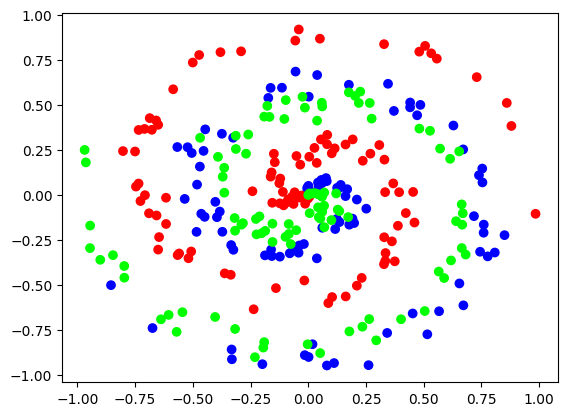

In [2]:

# Create dataset
X, y = spiral_data(samples=100, classes=3)

plt.scatter(X[:,0], X[:,1], c=y, cmap = 'brg')
plt.show()
# print(X)
# print(y)

## **Calculus Recap**

In this section, we revisit essential concepts from calculus that form the foundation of gradient-based optimization techniques in neural networks. Specifically, we will cover **partial derivatives**, the **gradient**, and the **chain rule**. These tools are crucial for understanding and implementing the backpropagation algorithm, which enables neural networks to learn from data.

---

### **Partial Derivatives**

Partial derivatives are a generalization of ordinary derivatives to functions of multiple variables. When a function $f(x_1, x_2, \dots, x_n)$ depends on several variables, the partial derivative with respect to one of these variables measures how $f$ changes when that specific variable changes, while all other variables remain constant.

The partial derivative of $f$ with respect to $x_i$ is denoted as:

$$
\frac{\partial f}{\partial x_i}
$$

For example, if $f(x, y) = x^2 + 3xy + y^2$, the partial derivatives are:

$$
\frac{\partial f}{\partial x} = 2x + 3y, \quad \frac{\partial f}{\partial y} = 3x + 2y
$$

---

### **The Gradient**

The gradient of a scalar function $f(x_1, x_2, \dots, x_n)$ is a vector that points in the direction of the steepest ascent of $f$. It is composed of all the partial derivatives of $f$ with respect to its variables:

$$
\nabla f = \begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}
$$

For the same example $f(x, y) = x^2 + 3xy + y^2$, the gradient is:

$$
\nabla f = \begin{bmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{bmatrix} =
\begin{bmatrix}
2x + 3y \\
3x + 2y
\end{bmatrix}
$$

The gradient is a key concept in gradient descent, as it guides us in updating parameters to minimize a given loss function.

---

### **The Chain Rule**

The chain rule allows us to compute the derivative of a composite function. If $z$ depends on $y$, and $y$ depends on $x$, then the rate of change of $z$ with respect to $x$ can be found using:

$$
\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}
$$

In the context of partial derivatives, if $f$ is a function of $u_1, u_2, \dots, u_m$, and each $u_i$ is a function of $x_1, x_2, \dots, x_n$, the chain rule is expressed as:

$$
\frac{\partial f}{\partial x_j} = \sum_{i=1}^m \frac{\partial f}{\partial u_i} \cdot \frac{\partial u_i}{\partial x_j}
$$

The chain rule is particularly important in neural networks for calculating gradients through layers of non-linear transformations.

---

By combining these concepts—partial derivatives, gradients, and the chain rule—we can derive the mathematical framework for **gradient descent**, the algorithm that enables neural networks to optimize their parameters and learn from data.


# **Lecture 5: Backpropagation**

Now that we understand how to measure the impact of variables on a function’s output, we can begin writing code to calculate partial derivatives and analyze their role in minimizing the model’s loss. To simplify the process, we’ll start by backpropagating the ReLU function for a single neuron, treating it as a demonstration exercise before applying it to a full neural network. The goal is to use the chain rule with derivatives and partial derivatives to understand how each variable affects the ReLU output, laying the groundwork for minimizing the overall loss later.

### Chain Rule

The chain rule is used to differentiate composite functions. If you have a function \( y = f(g(x)) \), the derivative is given by:

$$
\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)
$$

In our example:

$$
\begin{aligned}
f(x) &= \text{ReLU}(x), \\
g(x) &= x_1 \cdot w_1 + x_1 \cdot w_2 + x_1 \cdot w_3 + b, \\
\implies f(g(x)) &= \text{ReLU}(x_1 \cdot w_1 + x_1 \cdot w_2 + x_1 \cdot w_3 + b)
\end{aligned}
$$

The derivative of ReLU is given by:

$$
\begin{aligned}
f(x) &= \text{max}(x, 0), \\
\implies \frac{d}{dx}f(x) &= 1 \quad (x > 0), \\
&= 0 \quad (x \leq 0)
\end{aligned}
$$







### Chain Rule

The chain rule is used to differentiate composite functions. If you have a function \( y = f(g(x)) \), the derivative is given by:

$$
\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)
$$

In our example:

$$
\begin{aligned}
f(x) &= \text{ReLU}(x), \\
g(x) &= x_1 \cdot w_1 + x_1 \cdot w_2 + x_1 \cdot w_3 + b, \\
\implies f(g(x)) &= \text{ReLU}(x_1 \cdot w_1 + x_1 \cdot w_2 + x_1 \cdot w_3 + b)
\end{aligned}
$$

The derivative of ReLU is given by:

$$
\begin{aligned}
f(x) &= \text{max}(x, 0), \\
\implies \frac{d}{dx}f(x) &= 1 \quad (x > 0), \\
&= 0 \quad (x \leq 0)
\end{aligned}
$$

### Gradient Descent

In optimization, gradient descent is a method used to minimize a function iteratively. Given a loss function $ L(w) $, the weight updates are given by:

$$
w = w - \eta \cdot \nabla_w L(w)
$$

where:
- $ w $ is the weight,
- $ \eta $ is the learning rate,
- $ \nabla_w L(w) $ is the gradient of the loss function with respect to the weights.

For our example, the gradient of the loss with respect to the weights can be computed using the chain rule:

$$
\nabla_w L(w) = \frac{\partial L}{\partial f(g(x))} \cdot \frac{\partial f(g(x))}{\partial g(x)} \cdot \frac{\partial g(x)}{\partial w}
$$

Using the chain rule, we propagate the gradients backward from the output to the weights. In this case, the derivative of $ f(g(x)) $ with respect to $ g(x) $ depends on the ReLU function, and the derivative of $ g(x) $ with respect to $ w_1 $ is simply $ x_1 $.

Thus, the weight update rule becomes:

$$
w_1 = w_1 - \eta \cdot \frac{\partial L}{\partial f(g(x))} \cdot \frac{\partial f(g(x))}{\partial g(x)} \cdot x_1
$$

### Gradient Descent for Each Weight Component

Now, let's break down how the gradient descent works for each individual weight component $( w_1 ,  w_2 ,  w_3 )$.

- **For \( w_1 \):**
  The partial derivative of $ g(x) $ with respect to $ w_1 $ is $ x_1 $. So, the weight update rule for $ w_1 $ becomes:

  $$
  w_1 = w_1 - \eta \cdot \frac{\partial L}{\partial f(g(x))} \cdot \frac{\partial f(g(x))}{\partial g(x)} \cdot x_1
  $$

- **For \( w_2 \):**
  Similarly, the partial derivative of \( g(x) \) with respect to \( w_2 \) is \( x_2 \). Thus, the weight update rule for \( w_2 \) is:

  $$
  w_2 = w_2 - \eta \cdot \frac{\partial L}{\partial f(g(x))} \cdot \frac{\partial f(g(x))}{\partial g(x)} \cdot x_2
  $$

- **For \( w_3 \):**
  The partial derivative of \( g(x) \) with respect to \( w_3 \) is \( x_3 \). So the weight update rule for \( w_3 \) is:

  $$
  w_3 = w_3 - \eta \cdot \frac{\partial L}{\partial f(g(x))} \cdot \frac{\partial f(g(x))}{\partial g(x)} \cdot x_3
  $$

### Summary

The gradient descent updates each weight $ w_1 $, $ w_2 $, and $ w_3 $. The updates depend on the gradient of the loss with respect to the output of the ReLU function, which is propagated through the chain rule. The learning rate $ \eta $ controls how large the weight updates are in each iteration.



In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler # Deal with categorical data
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn # Neural Networks
import torch.nn.functional as F
import torch.optim as optim # Optimizers
from torch.utils.data import Dataset, DataLoader

/Users/manu13/anaconda3/envs/MLClass/lib/python3.9/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [4]:
pd.set_option('display.max_columns', None) # Visualize all columns

In [5]:
# We will stary by loading our kaggle data set

data_path = "./kaggle/train.csv" # This is the path where the data is located
data = pd.read_csv(data_path)
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

In [6]:
# data.info()

In [7]:
data = data.drop('Id', axis=1)

In [8]:
def onehot_encode(data, column, prefix=None):
    """
    One-hot encodes a specified column in the dataset.
    
    Parameters:
        data (pd.DataFrame): The input dataframe.
        column (str): The name of the column to encode.
        prefix (str, optional): The prefix for one-hot encoded column names. Defaults to the column name.
    
    Returns:
        pd.DataFrame: A dataframe with the specified column one-hot encoded.
    """
    data = data.copy()
    if prefix is None:
        prefix = column
    dummies = pd.get_dummies(data[column], prefix=prefix)
    data = pd.concat([data, dummies], axis=1)
    data = data.drop(column, axis=1)
    return data

In [9]:
# Identify non-numeric columns
non_numeric_cols = data.select_dtypes(include=['object']).columns

# Apply one-hot encoding to all non-numeric columns
for col in non_numeric_cols:
    data = onehot_encode(data, col, None)

# Display the updated datasetdata.head())
data.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Ex,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Ex,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_T

In [10]:
boolean_columns = data.select_dtypes(include=['bool']).columns
data[boolean_columns] = data[boolean_columns].astype(int)
data = data.dropna()
data.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Ex,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Ex,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_T

In [11]:
data.shape

(1121, 288)

In [12]:
y = data['SalePrice']
X = data.drop('SalePrice', axis=1).copy()

In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, random_state = 1)

## Pytorch Implementation

In [15]:
class PricePrediction(nn.Module):
    def __init__(self):
        super(PricePrediction, self).__init__()
        self.layer1 = nn.Linear(287, 512)
        self.layer2 = nn.Linear(512, 256)
        self.output = nn.Linear(256, 1)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.output(x)
        return x

In [16]:
model = PricePrediction()

# Visualize all the weights
# list(model.parameters())

# for i in range(len(list(model.parameters()))):
    # print(list(model.parameters())[i].shape)

In [17]:
# Conver data to torch tensors

t_X_train = torch.tensor(X_train).type(torch.float32)
t_y_train = torch.tensor(np.array(y_train)).type(torch.float32)

t_X_test = torch.tensor(X_test).type(torch.float32)
t_y_test = torch.tensor(np.array(y_test)).type(torch.float32)

In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Use the Adam Optimizer
criterion = nn.MSELoss() # Use MSE loss (one taught in class)

In [19]:
# Training
avg_losses = []
avg_val_losses = []
epochs = 250
for _ in range(epochs):
    losses = []
    val_losses = []
    for x, target in zip(t_X_train, t_y_train):
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, target)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
    avg_losses.append(np.mean(losses))

    for x, target in zip(t_X_test, t_y_test):
        output = model(x)
        loss = criterion(output, target)
        val_losses.append(loss.item())
    avg_val_losses.append(np.mean(val_losses))

    if _ % 10 == 0:
        print(f"Mean Loss: {np.mean(losses)} during epoch: {_}. Val Loss: {np.mean(val_losses)}")

/Users/manu13/anaconda3/envs/MLClass/lib/python3.9/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Mean Loss: 11091542912.392416 during epoch: 0. Val Loss: 5458351383.368114
Mean Loss: 563636526.5497274 during epoch: 10. Val Loss: 2191163251.2524805
Mean Loss: 278930724.5045851 during epoch: 20. Val Loss: 1511479658.4712074
Mean Loss: 183343080.33342883 during epoch: 30. Val Loss: 1695971583.0114384
Mean Loss: 165647086.608226 during epoch: 40. Val Loss: 2264345040.1716
Mean Loss: 108440669.98889627 during epoch: 50. Val Loss: 2040765938.4963865
Mean Loss: 72590943.9635505 during epoch: 60. Val Loss: 2304366401.916483
Mean Loss: 94452890.83553703 during epoch: 70. Val Loss: 1903329034.224082
Mean Loss: 66318637.90425484 during epoch: 80. Val Loss: 1667707880.1278992
Mean Loss: 67312343.35817765 during epoch: 90. Val Loss: 2209580129.154743
Mean Loss: 64847780.44102112 during epoch: 100. Val Loss: 2432395407.0759225
Mean Loss: 49407392.24172725 during epoch: 110. Val Loss: 2357568977.438307
Mean Loss: 48479507.40096324 during epoch: 120. Val Loss: 2064877599.4889884
Mean Loss: 458973

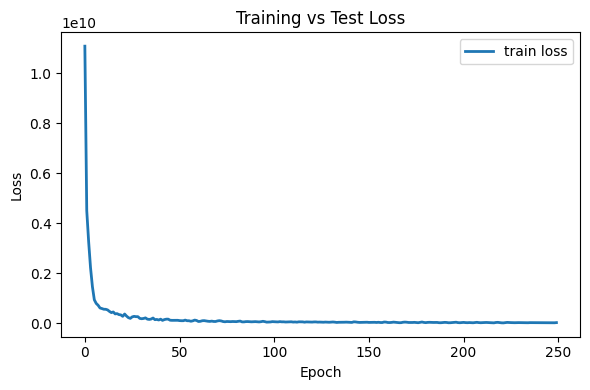

In [30]:
plt.figure(figsize=(6,4))
plt.plot(avg_losses, label="train loss", linewidth=2)
plt.title("Training vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

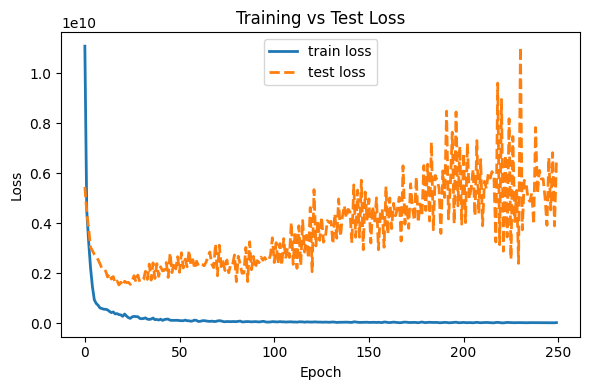

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(avg_losses, label="train loss", linewidth=2)
plt.plot(avg_val_losses, label="test loss", linewidth=2, linestyle="--")
plt.title("Training vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
total_loss = 0

# Testing Model with validation data

for x, target in zip(t_X_test, t_y_test):
    output = model(x)
    loss = criterion(output, target)
    total_loss += loss
    
avg_loss = total_loss / len(t_X_test)

In [28]:
# Return RMSE to compare performance with TF

torch_rmse = torch.sqrt(avg_loss).detach().numpy()

In [29]:
print("PyTorch RMSE:", torch_rmse)

# Pytorch performed better

PyTorch RMSE: 80739.57


### Question 1

Now it's your turn to implement a neural network! Using the provided **NNFS** dataset, create a simple neural network in both **PyTorch** and **TensorFlow** to perform a classification task. For this task, make sure to:

- Use **BCELoss** (Binary Cross-Entropy Loss) as your loss function.
- Apply the **Softmax** activation function in the output layer to normalize the predicted values into probabilities.

You can refer to the documentation for both libraries for more details on how to implement this. Try to compare the results between the two frameworks and see how they perform!

---

### Question 2

Can you implement a simple neural network from scratch that takes two values from the dataset as inputs? You’ll need to apply the backpropagation algorithm we’ve covered in class to train the network. This implementation should be very similar to the one discussed in **Lecture 3**, with the key difference being that **Lecture 3** uses a network without the ReLU activation.

Please refer to the **PDF** and **Lecture 3** for guidance. If you followed the steps there, this should be straightforward! You’ll need to ensure you're applying the right forward pass, loss function, and backpropagation steps as we learned.

---

Good luck! 😄
